# YAMNET Transfer learning


## The typical transfer-learning workflow

This leads us to how a typical transfer learning workflow can be implemented in Keras:

* Instantiate a base model and load pre-trained weights into it.
* Freeze all layers in the base model by setting trainable = False.
* Create a new model on top of the output of one (or several) layers from the base model.
* Train your new model on your new dataset.

Note that an alternative, more lightweight workflow could also be:

* Instantiate a base model and load pre-trained weights into it.
* Run your new dataset through it and record the output of one (or several) layers from the base model. This is called feature extraction.
* Use that output as input data for a new, smaller model.
* A key advantage of that second workflow is that you only run the base model once on your data, rather than once per epoch of training. So it's a lot faster & cheaper.


References: 
https://www.tensorflow.org/tutorials/audio/transfer_learning_audio


In [1]:
import pandas as pd
import tensorflow as tf 
import os
import tensorflow_hub as hub
import resampy
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import datetime

# Model specific
import params as yamnet_params
import yamnet as yamnet_model

print("running TF version",tf.__version__)

running TF version 2.9.2


In [3]:
# Clone model repo
!git clone https://github.com/tensorflow/models.git
%cd models/research/audioset/yamnet

# Download YAMNet data
!curl -O https://storage.googleapis.com/audioset/yamnet.h5

Cloning into 'models'...
remote: Enumerating objects: 82028, done.
remote: Counting objects: 100% (495/495), done.
remote: Compressing objects: 100% (225/225), done.
remote: Total 82028 (delta 314), reused 424 (delta 270), pack-reused 81533
Receiving objects: 100% (82028/82028), 596.41 MiB | 1.29 MiB/s, done.
Resolving deltas: 100% (58503/58503), done.
/Users/wetdog/Documents/01_personal/research/yamnet-transfer/models/research/audioset/yamnet
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 14.5M  100 14.5M    0     0  9977k      0  0:00:01  0:00:01 --:--:--  9.7M


# 1. Instantiate a base model and load pre-trained weights into it

In [2]:
# The graph is designed for a sampling rate of 16 kHz, but higher rates should work too.
# We also generate scores at a 10 Hz frame rate.
sr = 44100
params = yamnet_params.Params(sample_rate=sr, patch_hop_seconds=1)
print("Sample rate =", params.sample_rate)


# Set up the YAMNet model.
class_names = yamnet_model.class_names('yamnet_class_map.csv')
yamnet = yamnet_model.yamnet_frames_model(params)
yamnet.load_weights('yamnet.h5')

Sample rate = 44100
Metal device set to: Apple M2


2023-03-15 16:41:48.114152: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-03-15 16:41:48.114855: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
yamnet.summary()


Model: "yamnet_frames"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None,)]            0           []                               
                                                                                                  
 tf.compat.v1.shape (TFOpLambda  (1,)                0           ['input_1[0][0]']                
 )                                                                                                
                                                                                                  
 tf.__operators__.getitem (Slic  ()                  0           ['tf.compat.v1.shape[0][0]']     
 ingOpLambda)                                                                                     
                                                                                      

                                                                                                  
 layer3/depthwise_conv/bn (Batc  (None, 24, 16, 64)  192         ['layer3/depthwise_conv[0][0]']  
 hNormalization)                                                                                  
                                                                                                  
 layer3/depthwise_conv/relu (Re  (None, 24, 16, 64)  0           ['layer3/depthwise_conv/bn[0][0]'
 LU)                                                             ]                                
                                                                                                  
 layer3/pointwise_conv (Conv2D)  (None, 24, 16, 128)  8192       ['layer3/depthwise_conv/relu[0][0
                                                                 ]']                              
                                                                                                  
 layer3/po

 hNormalization)                                                                                  
                                                                                                  
 layer7/pointwise_conv/relu (Re  (None, 6, 4, 512)   0           ['layer7/pointwise_conv/bn[0][0]'
 LU)                                                             ]                                
                                                                                                  
 layer8/depthwise_conv (Depthwi  (None, 6, 4, 512)   4608        ['layer7/pointwise_conv/relu[0][0
 seConv2D)                                                       ]']                              
                                                                                                  
 layer8/depthwise_conv/bn (Batc  (None, 6, 4, 512)   1536        ['layer8/depthwise_conv[0][0]']  
 hNormalization)                                                                                  
          

 layer12/depthwise_conv/relu (R  (None, 6, 4, 512)   0           ['layer12/depthwise_conv/bn[0][0]
 eLU)                                                            ']                               
                                                                                                  
 layer12/pointwise_conv (Conv2D  (None, 6, 4, 512)   262144      ['layer12/depthwise_conv/relu[0][
 )                                                               0]']                             
                                                                                                  
 layer12/pointwise_conv/bn (Bat  (None, 6, 4, 512)   1536        ['layer12/pointwise_conv[0][0]'] 
 chNormalization)                                                                                 
                                                                                                  
 layer12/pointwise_conv/relu (R  (None, 6, 4, 512)   0           ['layer12/pointwise_conv/bn[0][0]
 eLU)     

In [4]:
embedding_layer = tf.keras.Model(inputs=yamnet.input,
                                 outputs=yamnet.get_layer('global_average_pooling2d').output)


In [5]:
embedding_layer.trainable = False

## Read metada csv file

convert labels to integers

In [8]:
metadata = pd.read_csv("../test_audioset_train_strong_filt_downloaded_v2.csv")
metadata.head()

,level_0,Unnamed: 0,segment_id,start_time_seconds,end_time_seconds,label,duration,clip_id,filename,index,mid,display_name
0,133330,667103,Bemu-8j_VGE_17000,7.375,7.692,/m/0gvgw0,0.317,-0x7b32841d4475ba1c,-0x7b32841d4475ba1c.wav,311,/m/0gvgw0,Air brake
1,133273,554781,10R2yQUbKzc_30000,2.870,3.096,/m/0gvgw0,0.226,-0x7815d3ae821d8fbd,-0x7815d3ae821d8fbd.wav,311,/m/0gvgw0,Air brake
2,133062,115126,6SOi-GYpwYk_0,3.537,4.230,/m/0gvgw0,0.693,-0x2653253b254bfd79,-0x2653253b254bfd79.wav,311,/m/0gvgw0,Air brake
3,133064,116726,pTrYhV3rrq8_30000,3.945,4.945,/m/0gvgw0,1.000,0x1eda2416e02fcb44,0x1eda2416e02fcb44.wav,311,/m/0gvgw0,Air brake
4,133411,849363,NPR5pHdvBW4_30000,6.787,7.351,/m/0gvgw0,0.564,0x4c0e29b89694b5cb,0x4c0e29b89694b5cb.wav,311,/m/0gvgw0,Air brake


In [10]:
audio_root = "/Volumes/AAC_Book/AUDIOSET_STRONG/"

metadata["path"] = audio_root + metadata["filename"].str

TypeError: can only concatenate str (not "StringMethods") to str

In [51]:
metadata["label_id"] = metadata["label"].astype("category").cat.codes

filenames = metadata["path"]
targets = metadata["label_id"]
n_classes = 66
embedding_size = 1024

def load_audio(filename):
    x, fs = sf.read(filename)
    if len(x.shape) > 1:
        x = np.mean(x, axis=1)
    return x


## Second approach

Run your new dataset through it and record the output of one (or several) layers from the base model. This is called feature extraction

In [52]:
filenames = metadata["path"]
targets = metadata["label_id"]


all_embeddings = np.empty([1,embedding_size])
all_labels = np.zeros(1)
for file, label in tqdm(zip(filenames, targets)):
    
    x = load_audio(file)
    embeddings = embedding_layer(x)
    all_embeddings = np.concatenate( [all_embeddings, embeddings] )
    all_labels = np.concatenate( [all_labels,np.repeat(label,embeddings.shape[0])] )


0it [00:00, ?it/s]

In [53]:

inputs = tf.keras.layers.Input(shape=(embedding_size), dtype=tf.float32,
                          name='input_embedding')
dense = tf.keras.layers.Dense(128, name='Hidden', activation="relu")(inputs)
outputs =  tf.keras.layers.Dense(n_classes, name="output",activation="softmax")(dense)


model = tf.keras.Model(inputs=inputs, outputs=outputs)


opt = tf.keras.optimizers.Adam(learning_rate=0.0001)
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="./logs")
model.compile(optimizer=opt,
              loss='categorical_crossentropy',
             metrics=["accuracy"],)
model.summary()

Model: "model_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_embedding (InputLayer  [(None, 1024)]           0         
 )                                                               
                                                                 
 Hidden (Dense)              (None, 128)               131200    
                                                                 
 output (Dense)              (None, 66)                8514      
                                                                 
Total params: 139,714
Trainable params: 139,714
Non-trainable params: 0
_________________________________________________________________


In [54]:
x_tf = tf.constant(all_embeddings, dtype=tf.float32)

y_tf = tf.keras.utils.to_categorical(all_labels, num_classes = n_classes)

(31756, 66)

In [59]:
start_date = datetime.datetime.strftime( datetime.datetime.now(), format="%Y%m%d_%H:%M:%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=f"./logs/{start_date}")
model.fit(x=x_tf,
         y=y_tf,
         epochs=150,
          callbacks=[tensorboard_callback],
         batch_size=16)

Epoch 1/150
1985/1985 [==============================] - 9s 5ms/step - loss: nan - accuracy: 0.0157
Epoch 2/150
1985/1985 [==============================] - 9s 5ms/step - loss: nan - accuracy: 0.0157
Epoch 3/150
1985/1985 [==============================] - 10s 5ms/step - loss: nan - accuracy: 0.0157
Epoch 4/150
1985/1985 [==============================] - 10s 5ms/step - loss: nan - accuracy: 0.0157
Epoch 5/150
1985/1985 [==============================] - 9s 5ms/step - loss: nan - accuracy: 0.0157
Epoch 6/150
1985/1985 [==============================] - 9s 5ms/step - loss: nan - accuracy: 0.0157
Epoch 7/150
1985/1985 [==============================] - 10s 5ms/step - loss: nan - accuracy: 0.0157
Epoch 8/150
1985/1985 [==============================] - 9s 5ms/step - loss: nan - accuracy: 0.0157
Epoch 9/150
1985/1985 [==============================] - 10s 5ms/step - loss: nan - accuracy: 0.0157
Epoch 10/150
1985/1985 [==============================] - 10s 5ms/step - loss: nan - accuracy: 0

KeyboardInterrupt: 

In [203]:
!tensorboard --logdir="./logs"

Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.9.1 at http://localhost:6006/ (Press CTRL+C to quit)
^C


In [133]:
all_embeddings.shape

print(all_labels.shape)

(96947,)


## Tf datasets approach

In [3]:
## Helper functins
@tf.function
def load_audio_16k_tf(filename):
    file = tf.io.read_file(filename)
    wav, sample_rate = tf.audio.decode_wav(
        file,
        desired_channels=1)
    wav = tf.squeeze(wav,axis=-1)
    if len(wav) ==0:
        wav = tf.zeros(4)
    return wav

def load_audio_resample(audio_file: str, target_sr:int=16000):
    """Load wav file and resample to a target frequency
        returns mono resampled signal"""

    x, sample_rate = sf.read(audio_file)
    # check for mono file
    if len(x.shape) > 1:
        x = x.mean(axis=1)
    # check sample rate of audio
    if sample_rate != target_sr:
        x = resampy.resample(x,sample_rate,target_sr)
    return x

In [7]:
## Load ESC-50 DATASET

DATASET_FOLDER = "/Users/wetdog/Documents/07_databases/ESC-50-master/meta/esc50.csv"
AUDIO_FOLDER = "/Users/wetdog/Documents/07_databases/ESC-50-master/audio"
df = pd.read_csv(DATASET_FOLDER)
df["filepath"] = df.apply(lambda x: os.path.join(AUDIO_FOLDER,x["filename"]), axis=1)
df.head()

,filename,fold,target,category,esc10,src_file,take,filepath
0,1-100032-A-0.wav,1,0,dog,True,100032,A,/Users/wetdog/Documents/07_databases/ESC-50-ma...
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,/Users/wetdog/Documents/07_databases/ESC-50-ma...
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A,/Users/wetdog/Documents/07_databases/ESC-50-ma...
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B,/Users/wetdog/Documents/07_databases/ESC-50-ma...
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A,/Users/wetdog/Documents/07_databases/ESC-50-ma...


In [35]:
WINDOW_SIZE_SAMPLES = 1024
HOP_SIZE_SAMPLES = 512

filepath = df["filepath"].iloc[0]
x, fs = sf.read(filepath)
signal = tf.Tensor(x,dtype=tf.float32)
print(x.shape)
X = tf.signal.stft(signal,frame_length=WINDOW_SIZE_SAMPLES,
                frame_step=HOP_SIZE_SAMPLES)
X_mag = tf.abs(X)

mel_filterbank = tf.signal.linear_to_mel_weight_matrix(num_mel_bins=64,
                num_spectrogram_bins=513,
                sample_rate=fs,
                lower_edge_hertz=60.0,
                upper_edge_hertz=8000.0,

                name=None,)

print(mel_filterbank.shape)
print(X_mag.shape)

X_mel = tf.matmul(tf.square(X_mag),mel_filterbank)

TypeError: __init__() missing 1 required positional argument: 'value_index'

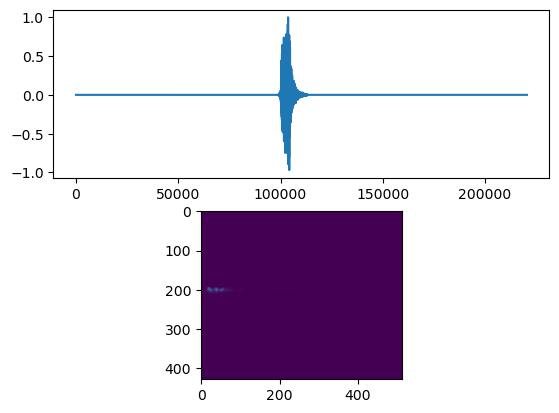

In [18]:
fig, ax = plt.subplots(nrows=2,ncols=1)

ax[0].plot(x)
ax[1].imshow(X_mag)

In [10]:
tf.signal.stft?

Signature:
tf.signal.stft(
    signals,
    frame_length,
    frame_step,
    fft_length=None,
    window_fn=<function hann_window at 0x17a50e160>,
    pad_end=False,
    name=None,
)
Docstring:
Computes the [Short-time Fourier Transform][stft] of `signals`.

Implemented with TPU/GPU-compatible ops and supports gradients.

Args:
  signals: A `[..., samples]` `float32`/`float64` `Tensor` of real-valued
    signals.
  frame_length: An integer scalar `Tensor`. The window length in samples.
  frame_step: An integer scalar `Tensor`. The number of samples to step.
  fft_length: An integer scalar `Tensor`. The size of the FFT to apply.
    If not provided, uses the smallest power of 2 enclosing `frame_length`.
  window_fn: A callable that takes a window length and a `dtype` keyword
    argument and returns a `[window_length]` `Tensor` of samples in the
    provided datatype. If set to `None`, no windowing is used.
  pad_end: Whether to pad the end of `signals` with zeros when the provided
   

In [ ]:
def process_audioclio(filepath):
    x, fs = sf.read(filepath)
    tf.signal.fft(frame_length=WINDOW_SIZE_SAMPLES,
                    frame_step=HOP_SIZE_SAMPLES))

In [ ]:
# preprocess dataset


In [5]:
# define model 
yamnet_handle = 'https://tfhub.dev/google/yamnet/1'
yamnet = hub.load(yamnet_handle)

Metal device set to: Apple M2

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB



2022-10-21 18:32:07.131172: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2022-10-21 18:32:07.131438: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [ ]:
model = tf.keras.Input(tens)

In [34]:
# test loading function 

x = load_audio_resample(df["filepath"].iloc[4],16000)

In [48]:
filenames = df["filepath"]
targets = df["target"]
folds = df["fold"]

main_ds = tf.data.Dataset.from_tensor_slices((filenames,targets,folds))
main_ds.element_spec

(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [42]:
main_ds

<TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [49]:
def load_wav_for_map(filename, label, fold):
    load_audio_16k_tf(filename), label, fold

main_ds = main_ds.map(load_wav_for_map)

InvalidArgumentError: Length for attr 'output_shapes' of 0 must be at least minimum 1
	; NodeDef: {{node MapDataset}}; Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=metadata:string,default=""> [Op:MapDataset]